# TCC: 03 - Análise Exploratória e Fusão de Bases (Merge Longitudinal)

Neste notebook, iniciamos a exploração visual das duas grandes bases já padronizadas (SIH e CNES) e realizamos o cruzamento rigoroso utilizando **Data (Mês/Ano) + Hospital** para evitar data-leakage e garantir a foto histórica exata da infraestrutura hospitalar.

In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Configurações gráficas estritas conforme normas da instituição
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
    "font.size": 11,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "axes.grid": False,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False
})
sns.set_style("white")
def enforce_tcc_style():
    import matplotlib.pyplot as plt
    import seaborn as sns
    try:
        plt.grid(False)
        sns.despine(top=True, right=True, left=False, bottom=False)
        for ax_ in plt.gcf().axes:
            ax_.grid(False)
            ax_.spines['top'].set_visible(False)
            ax_.spines['right'].set_visible(False)
            ax_.spines['bottom'].set_linewidth(1.5)
            ax_.spines['bottom'].set_color('black')
            ax_.spines['left'].set_linewidth(1.5)
            ax_.spines['left'].set_color('black')
            ax_.tick_params(colors='black', width=1.5)
            if ax_.get_title(): ax_.set_title('')
    except Exception: pass


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import sys

# Adiciona a raiz do projeto
ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))

INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'

# sns.set_theme(style="whitegrid", palette="muted") # SOBRESCRITO PELO TCC


## 1. Carregamento das Bases de Modelagem

In [15]:
# Carrega apenas as bases prontas para modelagem (sem _cod)
df_sih = pd.read_csv(INTERIM / "sih_iam_modelagem.csv", low_memory=False)
df_cnes = pd.read_csv(INTERIM / "cnes_hospitais_modelagem.csv", low_memory=False)

print(f"SIH-IAM: {df_sih.shape[0]:,} internações")
print(f"CNES:    {df_cnes.shape[0]:,} fotos hospitalares (meses)")

SIH-IAM: 415,367 internações
CNES:    62,552 fotos hospitalares (meses)


In [16]:
print(df_cnes.columns.tolist())

['codigo_cnes', 'cep_estabelecimento', 'cpf_cnpj_estabelecimento', 'cnpj_mantenedora', 'codigo_regiao_saude', 'vinculo_sus_cod', 'codigo_fluxo_clientela_cod', 'codigo_turno_atendimento_cod', 'tipo_prestador_cod', 'codigo_banco', 'codigo_agencia', 'conta_corrente', 'numero_alvara', 'data_expedicao_alvara_cod', 'gestao_ab_ambulatorial_municipal', 'gestao_mc_ambulatorial_municipal', 'gestao_ac_ambulatorial_municipal', 'nivel_atencao_ambulatorial', 'gestao_programa03_municipal', 'gestao_mc_hospitalar_municipal', 'gestao_ac_hospitalar_municipal', 'nivel_atencao_hospitalar', 'qtd_leitos_cirurgicos', 'qtd_leitos_clinicos', 'qtd_leitos_complementares', 'possui_leitos_hospitalares', 'qtd_instalacao_01', 'qtd_instalacao_02', 'qtd_instalacao_03', 'qtd_instalacao_04', 'qtd_instalacao_05', 'qtd_instalacao_06', 'qtd_instalacao_07', 'qtd_instalacao_08', 'qtd_instalacao_09', 'qtd_instalacao_10', 'qtd_instalacao_11', 'qtd_instalacao_12', 'qtd_instalacao_13', 'qtd_instalacao_14', 'possui_urgencia_emerge

In [17]:
print(df_cnes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62552 entries, 0 to 62551
Columns: 561 entries, codigo_cnes to habilitacao_908
dtypes: float64(377), int64(145), object(39)
memory usage: 267.7+ MB
None


## 2. Análise Exploratória Rápida (EDA)

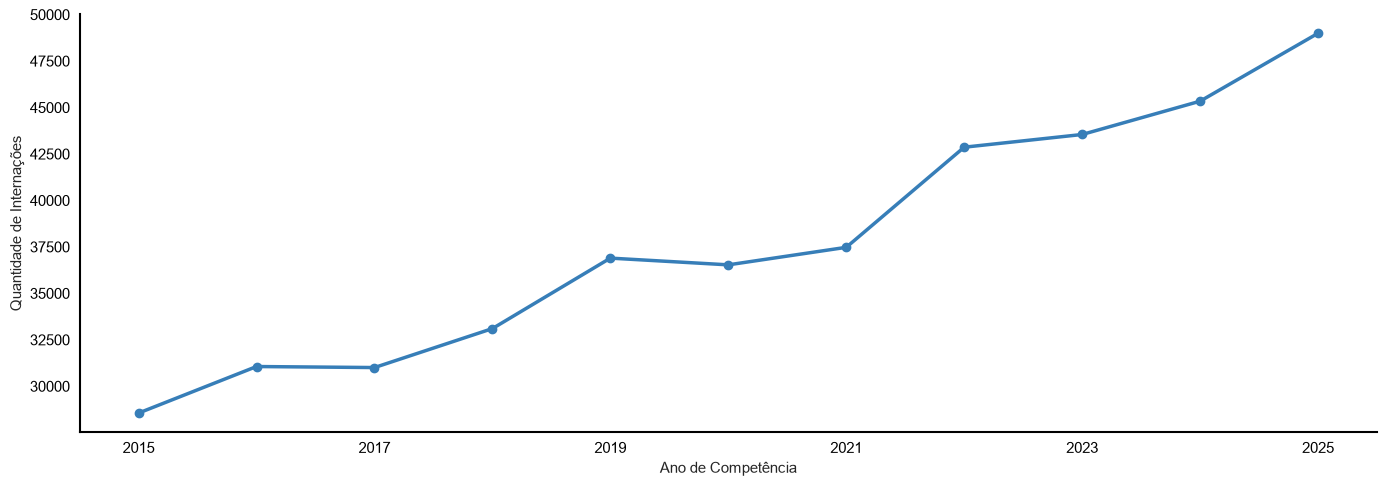

Figura salva: eda_evolucao_temporal.jpg


In [25]:
FIG_PATH_03 = Path('../reports/figures')
FIG_PATH_03.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np

# Paleta viridis para uso consistente
_vir = plt.cm.coolwarm

# ── 1. Evolução temporal do IAM ──────────────────────────────────────────────
df_sih['ano_competencia'] = df_sih['ano_competencia'].astype(str).str.replace('.0', '', regex=False)
df_sih['mes_competencia'] = df_sih['mes_competencia'].astype(str).str.replace('.0', '', regex=False).str.zfill(2)
df_sih['competencia'] = df_sih['ano_competencia'] + df_sih['mes_competencia']

fig, ax = plt.subplots(figsize=(14, 5))
df_sih.groupby('ano_competencia').size().plot(kind='line', marker='o', color="#377EB8", linewidth=2.5, ax=ax)
# TÍTULO REMOVIDO — legenda inserida abaixo da figura no Word (norma TCC)
ax.set_ylabel('Quantidade de Internações')
ax.set_xlabel('Ano de Competência')
ax.grid(False)
plt.tight_layout()
enforce_tcc_style()
plt.savefig(FIG_PATH_03 / 'eda_evolucao_temporal.jpg', dpi=300, bbox_inches='tight')
plt.show()
print('Figura salva: eda_evolucao_temporal.jpg')






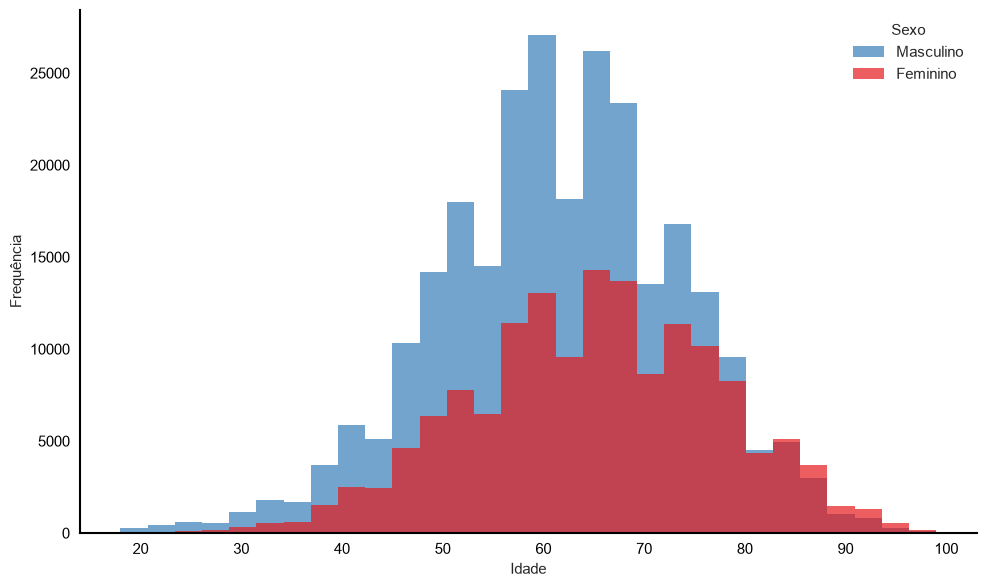

Figura salva: eda_dist_etaria_sexo.jpg


In [28]:
# ── 2. Distribuição Etária por Sexo ─────────────────────────────────────────

df_sih['idade_num'] = pd.to_numeric(
    df_sih['idade'],
    errors='coerce'
)

fig, ax = plt.subplots(figsize=(10, 6))

# Ordem de desenho: Masculino primeiro, Feminino depois
sexos = ['Masculino', 'Feminino']

cores_sexo = {
    'Masculino': '#377EB8',  # vermelho
    'Feminino': '#E41A1C'    # azul
}

for sexo in sexos:

    dados = df_sih.loc[
        df_sih['sexo'] == sexo,
        'idade_num'
    ].dropna()

    ax.hist(
        dados,
        bins=30,
        label=sexo,
        alpha=0.7,
        color=cores_sexo[sexo],
        edgecolor='none'
    )

# TÍTULO REMOVIDO — norma TCC

ax.set_xlabel('Idade')
ax.set_ylabel('Frequência')

ax.legend(
    title='Sexo',
    frameon=False
)

ax.grid(False)

plt.tight_layout()

enforce_tcc_style()

plt.savefig(
    FIG_PATH_03 / 'eda_dist_etaria_sexo.jpg',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Figura salva: eda_dist_etaria_sexo.jpg')

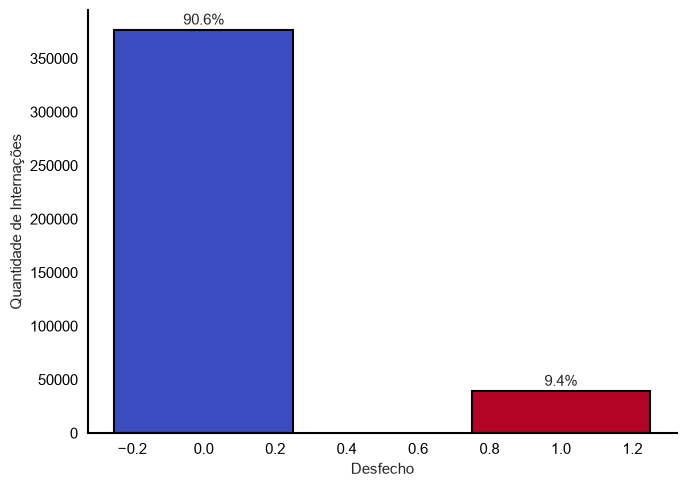

Figura salva: eda_desfecho_hospitalar.jpg


In [22]:
# ── 3. Desfecho Hospitalar ───────────────────────────────────────────────────
desfecho_col = next((c for c in df_sih.columns if 'desfecho' in c.lower() or 'obito' in c.lower()), None)
if desfecho_col:
    contagem = df_sih[desfecho_col].value_counts()
    total = contagem.sum()
    labels = contagem.index.tolist()
    vals = contagem.values
    n_cat = len(labels)
    cores_def = [_vir(i / max(n_cat - 1, 1)) for i in range(n_cat)]
    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(labels, vals, color=cores_def, edgecolor='black', linewidth=1.5, width=0.5)
    for bar, val in zip(bars, vals):
        ax.annotate(f'{val/total*100:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', fontsize=11)
    ax.set_xlabel('Desfecho')
    ax.set_ylabel('Quantidade de Internações')
    ax.grid(False)
    plt.tight_layout()
    enforce_tcc_style()
    plt.savefig(FIG_PATH_03 / 'eda_desfecho_hospitalar.jpg', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figura salva: eda_desfecho_hospitalar.jpg')
else:
    print('⚠️  Coluna de desfecho não encontrada — verifique nome da coluna.')


In [19]:

for i, col in enumerate(df_sih.columns, 1):
    print(
        i,
        col,
        df_sih[col].dtype,
        df_sih[col].dropna().iloc[0] if df_sih[col].notna().any() else "Sem valores"
    )

1 ano_competencia object 2015
2 mes_competencia object 01
3 especialidade_leito_cod int64 3
4 cnpj_hospital float64 57740490000260.0
5 numero_aih_cod int64 3514116185327
6 cep_paciente int64 11713110
7 municipio_residencia_cod int64 354100
8 data_nascimento object 1957-11-24
9 uti_mes_inicial int64 0
10 uti_mes_anterior int64 0
11 uti_mes_alta int64 0
12 uti_mes_total_cod int64 0
13 uti_intermediaria_inicial int64 0
14 uti_intermediaria_anterior int64 0
15 uti_intermediaria_alta int64 0
16 uti_intermediaria_total int64 0
17 diarias_acompanhante int64 0
18 quantidade_diarias int64 28
19 procedimento_solicitado int64 303060190
20 procedimento_realizado_cod int64 303060190
21 valor_servicos_hospitalares float64 748.75
22 valor_servicos_profissionais float64 170.9
23 valor_sadt float64 0.0
24 valor_rn float64 0.0
25 valor_acompanhante float64 0.0
26 valor_ortese_protese float64 0.0
27 valor_sangue float64 0.0
28 valor_sadtsr float64 0.0
29 valor_transporte float64 0.0
30 valor_obsang float

In [20]:
count_dias = (
    df_sih['dias_permanencia_cod']
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis('dias_permanencia_cod')
    .reset_index(name='count')
)

count_dias

,dias_permanencia_cod,count
0,0,27676
1,1,52122
2,2,41689
3,3,45430
4,4,41074
...,...,...
126,150,1
127,185,1
128,188,1
129,205,1


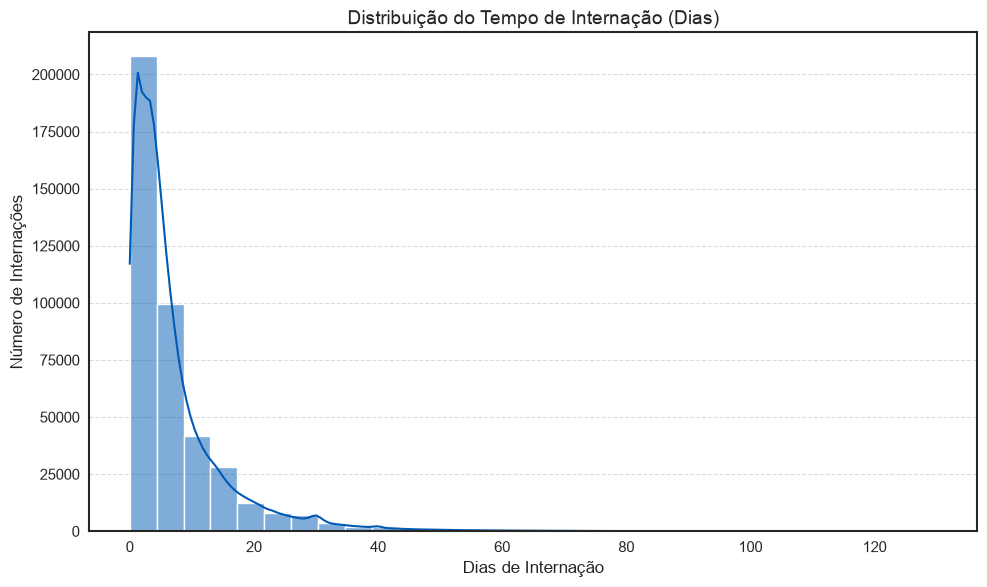

In [21]:
def plot_tempo_internacao(df, coluna_dias='dias_permanencia_cod'):
    plt.figure(figsize=(10, 6))
    
    # Filtra valores extremos para melhor visualização (ex: foca nos primeiros 30 dias)
    dados_plot = df[df[coluna_dias] <= 130][coluna_dias].dropna()
    
    sns.histplot(dados_plot, bins=30, color="#005AB5", kde=True)
    plt.title("Distribuição do Tempo de Internação (Dias)", fontsize=14)
    plt.xlabel("Dias de Internação", fontsize=12)
    plt.ylabel("Número de Internações", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Para usar:
plot_tempo_internacao(df_sih)

## 3. Preparação das Chaves Longitudinais

In [10]:
# 1. Cria a chave de competência (YYYYMM) no SIH para coincidir com o CNES
df_sih['competencia'] = df_sih['ano_competencia'] + df_sih['mes_competencia']

# 2. Garante que os tipos das chaves sejam idênticos em ambas as bases
df_sih['codigo_cnes'] = df_sih['codigo_cnes'].astype(str).str.strip().str.zfill(7)
df_sih['competencia'] = df_sih['competencia'].astype(str).str.strip()

df_cnes['codigo_cnes'] = df_cnes['codigo_cnes'].astype(str).str.strip().str.zfill(7)
df_cnes['competencia'] = df_cnes['competencia'].astype(str).str.strip()

print("Amostra de chaves (SIH):")
print(df_sih[['codigo_cnes', 'competencia']].head())
print("\nAmostra de chaves (CNES):")
print(df_cnes[['codigo_cnes', 'competencia']].head())

Amostra de chaves (SIH):
  codigo_cnes competencia
0     2087804      201501
1     2091755      201501
2     2091755      201501
3     2091755      201501
4     2077396      201501

Amostra de chaves (CNES):
  codigo_cnes competencia
0     2077647      201501
1     2077558      201501
2     2774720      201501
3     2716593      201501
4     2080508      201501


## 4. O Grande Merge Longitudinal

Fazemos o `Left Join` usando Hospital + Mês. Assim, a infraestrutura hospitalar refletida no modelo de IA será a que existia **naquele exato mês da internação**.

In [11]:
# Left Join no nível Hospital-Mês
df_base_modelagem = pd.merge(
    df_sih,
    df_cnes,
    on=['codigo_cnes', 'competencia'],
    how='left',
    suffixes=('', '_cnes')
)

print(f"Linhas ANTES do merge:  {len(df_sih):,}")
print(f"Linhas DEPOIS do merge: {len(df_base_modelagem):,}")

# Validação de Match
# Verificamos quantos hospitais foram encontrados na base CNES naquele mês exato
taxa_match = df_base_modelagem['cep_estabelecimento'].notnull().mean() * 100
print(f"\nTaxa de sucesso do cruzamento (Match rate): {taxa_match:.2f}%")

if taxa_match < 50:
    print("\n⚠️ ALERTA: Match rate muito baixo! Isso geralmente ocorre quando a base do CNES baixada não contempla os mesmos anos/meses da base SIH.")


Linhas ANTES do merge:  415,367
Linhas DEPOIS do merge: 415,367

Taxa de sucesso do cruzamento (Match rate): 100.00%


## 5. Exportação da Base Final

In [12]:
path_base_final = PROCESSED / "base_modelagem.csv"
df_base_modelagem.to_csv(path_base_final, index=False)
print(f"✅ Base final exportada para {path_base_final}")

✅ Base final exportada para /home/carolina/Documents/TCC Documentos/TCC/data/processed/base_modelagem.csv
